# Notebook 3 — Product Utilization Analysis
**European Bank Customer Churn Analysis**

> Examine how product depth (1–4 products) drives churn. Single vs multi-product retention and the product-depth vs churn relationship.

---

## Setup & Data Load

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#E8E6DE',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'purple': '#7F77DD',
    'red':    '#E24B4A',
    'gray':   '#888780',
    'green':  '#639922',
    'pink':   '#D4537E',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('European_Bank.csv')
churn_rate = df['Exited'].mean() * 100
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns  |  Churn rate: {churn_rate:.1f}%')

Loaded: 10,000 rows × 14 columns  |  Churn rate: 20.4%


In [3]:
# ── Pre-compute shared fields ──────────────────────────────────────────────
HIGH_BALANCE_THRESHOLD = df['Balance'].quantile(0.75)
BALANCE_THRESHOLD      = df[df['Balance'] > 0]['Balance'].median()

# Engagement profile
def classify_engagement(row):
    active   = row['IsActiveMember'] == 1
    multi    = row['NumOfProducts']  >= 2
    high_bal = row['Balance'] >= HIGH_BALANCE_THRESHOLD and row['Balance'] > 0
    if active and multi:               return 'Active Engaged'
    elif not active and not multi and row['Balance'] == 0: return 'Inactive Disengaged'
    elif active and not multi:         return 'Active Low-Product'
    elif not active and high_bal:      return 'Inactive High-Balance'
    else:                              return 'Mixed'

df['EngagementProfile']    = df.apply(classify_engagement, axis=1)
df['ProductTier']          = df['NumOfProducts'].apply(
    lambda x: 'Single (1)' if x == 1 else ('Dual (2)' if x == 2 else 'Power (3-4)'))

salary_75  = df['EstimatedSalary'].quantile(0.75)
balance_25 = df[df['Balance'] > 0]['Balance'].quantile(0.25)
df['SalaryBalanceMismatch'] = (
    (df['EstimatedSalary'] >= salary_75) &
    ((df['Balance'] == 0) | (df['Balance'] < balance_25))
)
bal_75 = df['Balance'].quantile(0.75)
sal_75 = df['EstimatedSalary'].quantile(0.75)
df['IsPremium']       = (df['Balance'] >= bal_75) & (df['EstimatedSalary'] >= sal_75)
df['IsAtRiskPremium'] = df['IsPremium'] & (df['IsActiveMember'] == 0)

def sticky_score(row):
    s = 0
    if row['IsActiveMember'] == 1:        s += 2
    if row['NumOfProducts'] >= 2:          s += 2
    if row['HasCrCard'] == 1:              s += 1
    if row['Balance'] > BALANCE_THRESHOLD: s += 2
    if row['Tenure'] >= 5:                 s += 1
    if row['CreditScore'] >= 700:          s += 1
    return s
df['StickyScore'] = df.apply(sticky_score, axis=1)
df['StickyTier']  = pd.cut(df['StickyScore'], bins=[-1,2,5,7,9],
    labels=['Low (0-2)','Medium (3-5)','High (6-7)','Very High (8-9)'])

print('Shared features computed ✓')

Shared features computed ✓


## 3.1 — Churn Rate by Number of Products

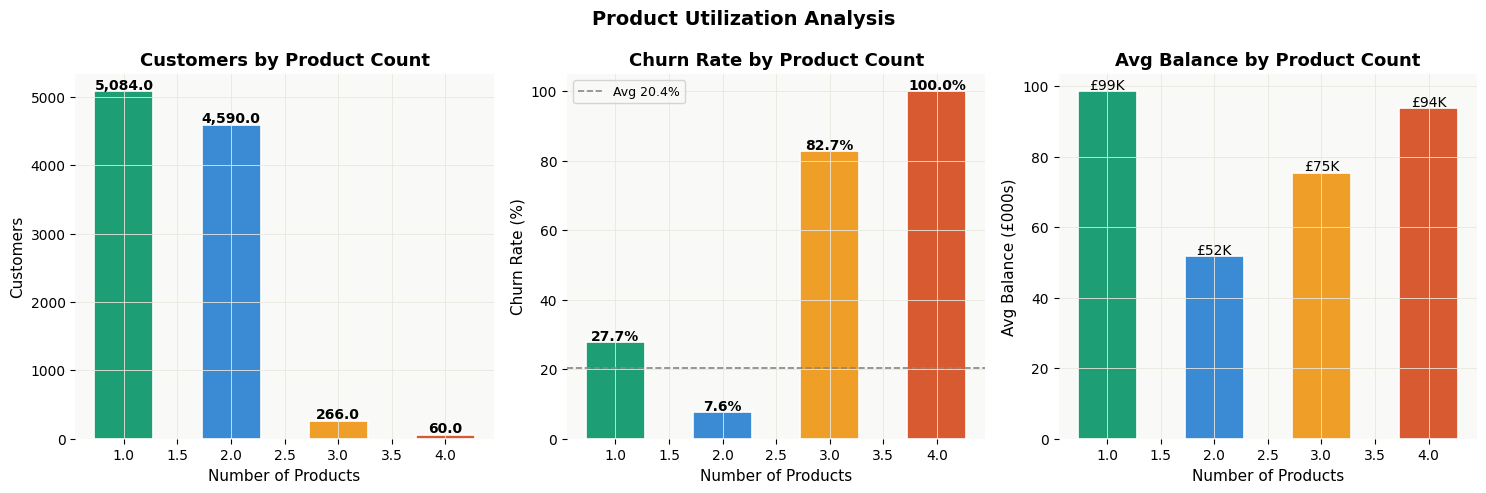

 NumOfProducts  Count  Churned  Churn_Pct  Avg_Balance
             1   5084     1409  27.714398 98551.870614
             2   4590      348   7.581699 51879.145813
             3    266      220  82.706767 75458.328195
             4     60       60 100.000000 93733.135000


In [4]:
product_stats = df.groupby('NumOfProducts').agg(
    Count       = ('Exited', 'count'),
    Churned     = ('Exited', 'sum'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Avg_CreditScore = ('CreditScore', 'mean')
).reset_index()
product_stats['Churn_Pct'] = product_stats['Churn_Rate'] * 100

bar_colors = [PALETTE['teal'], PALETTE['blue'], PALETTE['amber'], PALETTE['coral']]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Product Utilization Analysis', fontweight='bold', fontsize=14)

axes[0].bar(product_stats['NumOfProducts'], product_stats['Count'],
            color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)
axes[0].set_title('Customers by Product Count')
axes[0].set_xlabel('Number of Products'); axes[0].set_ylabel('Customers')
for _, row in product_stats.iterrows():
    axes[0].text(row['NumOfProducts'], row['Count']+30,
                 f"{row['Count']:,}", ha='center', fontsize=10, fontweight='bold')

bars = axes[1].bar(product_stats['NumOfProducts'], product_stats['Churn_Pct'],
                   color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)
axes[1].axhline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1.2,
                label=f'Avg {churn_rate:.1f}%')
axes[1].set_title('Churn Rate by Product Count')
axes[1].set_xlabel('Number of Products'); axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend(fontsize=9)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(product_stats['NumOfProducts'], product_stats['Avg_Balance']/1000,
            color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)
axes[2].set_title('Avg Balance by Product Count')
axes[2].set_xlabel('Number of Products'); axes[2].set_ylabel('Avg Balance (£000s)')
for _, row in product_stats.iterrows():
    axes[2].text(row['NumOfProducts'], row['Avg_Balance']/1000+0.5,
                 f"£{row['Avg_Balance']/1000:.0f}K", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_06_product_utilization.png', dpi=150, bbox_inches='tight')
plt.show()
print(product_stats[['NumOfProducts','Count','Churned','Churn_Pct','Avg_Balance']].to_string(index=False))

## 3.2 — Single vs Multi-Product Retention

Single vs Multi-Product Retention Summary
──────────────────────────────────────────────────────────────────────
ProductTier  Count    Churn%  Avg_Balance  ActiveMember%   HasCC%
   Dual (2)   4590  7.581699 51879.145813       0.532898 0.707190
Power (3-4)    326 85.889571 78821.789571       0.435583 0.708589
 Single (1)   5084 27.714398 98551.870614       0.504131 0.703777


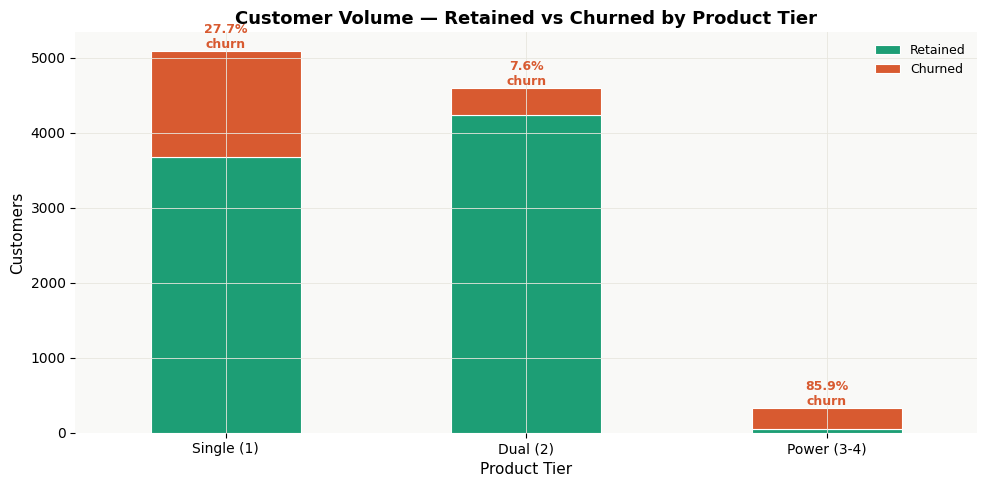

In [6]:
tier_stats = df.groupby('ProductTier').agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Active_Rate = ('IsActiveMember', 'mean'),
    HasCC_Rate  = ('HasCrCard', 'mean')
).reset_index()
tier_stats['Churn_Pct'] = tier_stats['Churn_Rate'] * 100

print('Single vs Multi-Product Retention Summary')
print('─' * 70)
print(tier_stats[['ProductTier','Count','Churn_Pct','Avg_Balance','Active_Rate','HasCC_Rate']]
      .rename(columns={'Churn_Pct':'Churn%','Active_Rate':'ActiveMember%','HasCC_Rate':'HasCC%'})
      .to_string(index=False))

tier_order  = ['Single (1)', 'Dual (2)', 'Power (3-4)']
tier_counts = df.groupby(['ProductTier', 'Exited']).size().unstack(fill_value=0).reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
tier_counts.plot(kind='bar', stacked=True, ax=ax,
                 color=[PALETTE['teal'], PALETTE['coral']],
                 edgecolor='white', linewidth=0.8, width=0.5)
ax.set_title('Customer Volume — Retained vs Churned by Product Tier', fontweight='bold')
ax.set_xlabel('Product Tier'); ax.set_ylabel('Customers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Retained', 'Churned'], frameon=False, fontsize=9)
for i, tier in enumerate(tier_order):
    subset = df[df['ProductTier'] == tier]
    rate  = subset['Exited'].mean() * 100
    total = len(subset)
    ax.text(i, total+50, f'{rate:.1f}%\nchurn', ha='center', fontsize=9,
            color=PALETTE['coral'], fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_product_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 — Product Depth vs Churn (Cross-Tab Heatmap)

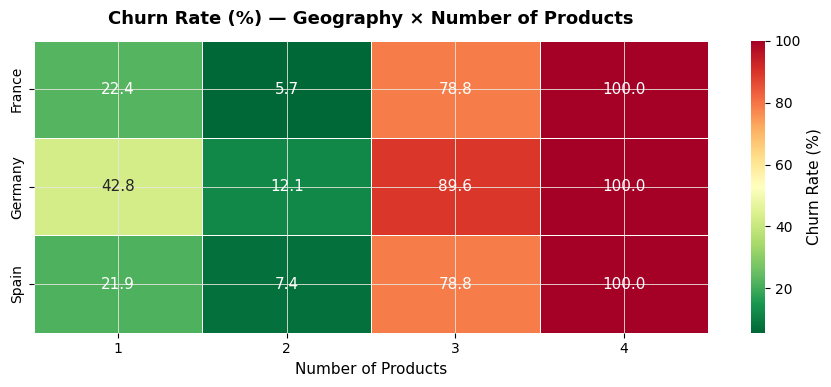

In [7]:
pivot = df.groupby(['Geography', 'NumOfProducts'])['Exited'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) — Geography × Number of Products', fontweight='bold', pad=12)
ax.set_xlabel('Number of Products'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_07b_product_geo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()